# Kronecker products and sums

This notebook develops the matrix construction used for separable multidimensional models. It emphasizes dimensions, ordering, sparsity, eigenvalues, and visual interpretation.

## Objectives

- construct $A\otimes B$ and recognize its block structure;
- verify its action on product vectors;
- construct a two-dimensional operator as a Kronecker sum;
- connect one-dimensional eigenpairs to two-dimensional eigenpairs;
- visualize sparse structure and separable modes.

All examples are deterministic and dimensionless.

## 1. Kronecker product

For $A\in\mathbb{R}^{m\times n}$ and $B\in\mathbb{R}^{p\times q}$,

$$
A\otimes B=
\begin{bmatrix}
a_{11}B & \cdots & a_{1n}B\\
\vdots & \ddots & \vdots\\
a_{m1}B & \cdots & a_{mn}B
\end{bmatrix}
\in\mathbb{R}^{mp\times nq}.
$$

Each scalar entry of $A$ scales an entire copy of $B$.

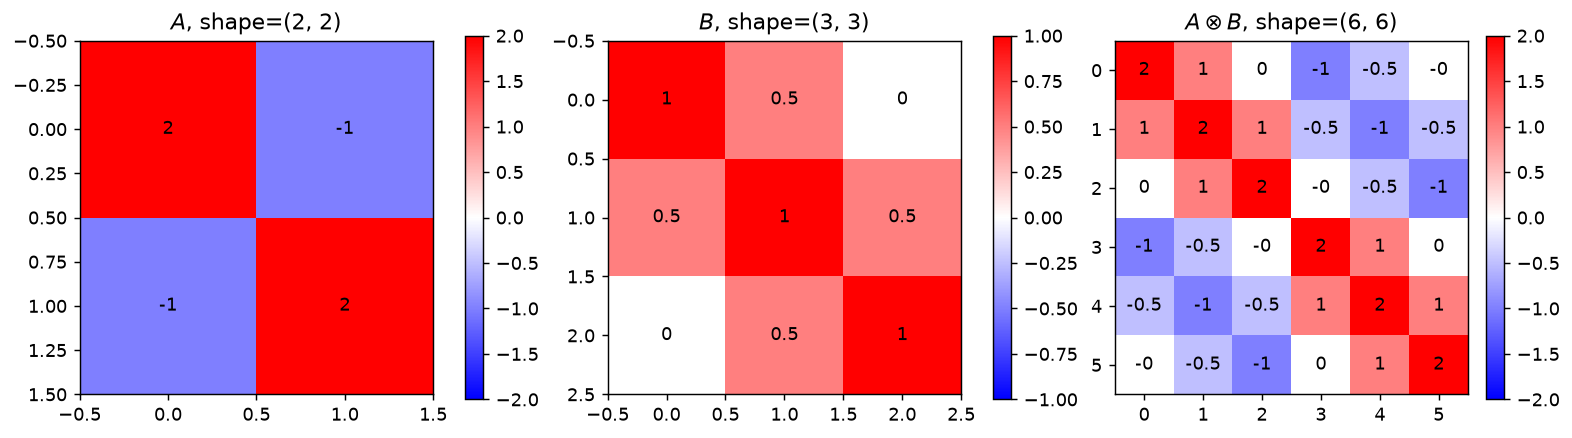

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse

from physkit.visualize import HeatMapVisualizer

A = np.array([[2.0, -1.0], [-1.0, 2.0]])
B = np.array([[1.0, 0.5, 0.0], [0.5, 1.0, 0.5], [0.0, 0.5, 1.0]])
A_kron_B = np.kron(A, B)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for axis, matrix, title in zip(
    axes,
    (A, B, A_kron_B),
    (r"$A$", r"$B$", r"$A\otimes B$"),
):
    HeatMapVisualizer(matrix).plot(
        axis,
        annotate=True,
        title=f"{title}, shape={matrix.shape}",
    )
plt.show()


## 2. Action on product vectors

For compatible vectors $x$ and $y$,

$$
(A\otimes B)(x\otimes y)=(Ax)\otimes(By).
$$

This identity lets a multidimensional action be understood through lower-dimensional factors. The ordering of entries still matters: throughout this notebook, a field with shape $(N_x,N_y)$ is flattened in C order, so the $y$ index varies fastest.

In [2]:
x = np.array([1.0, -2.0])
y = np.array([0.5, 1.0, -1.0])
left = np.kron(A, B) @ np.kron(x, y)
right = np.kron(A @ x, B @ y)
error = np.linalg.norm(left - right)
print(f"product-vector identity error: {error:.3e}")
print(f"output dimension: {left.size}")


product-vector identity error: 0.000e+00
output dimension: 6


## 3. Kronecker sum for a two-dimensional operator

Let $T_x$ and $T_y$ be positive one-dimensional Dirichlet kinetic matrices. On a rectangular tensor-product grid,

$$
T_{2D}=T_x\otimes I_y+I_x\otimes T_y.
$$

The first term acts along $x$ while preserving $y$; the second acts along $y$ while preserving $x$. Sparse construction retains the nearest-neighbor stencil without allocating every zero.

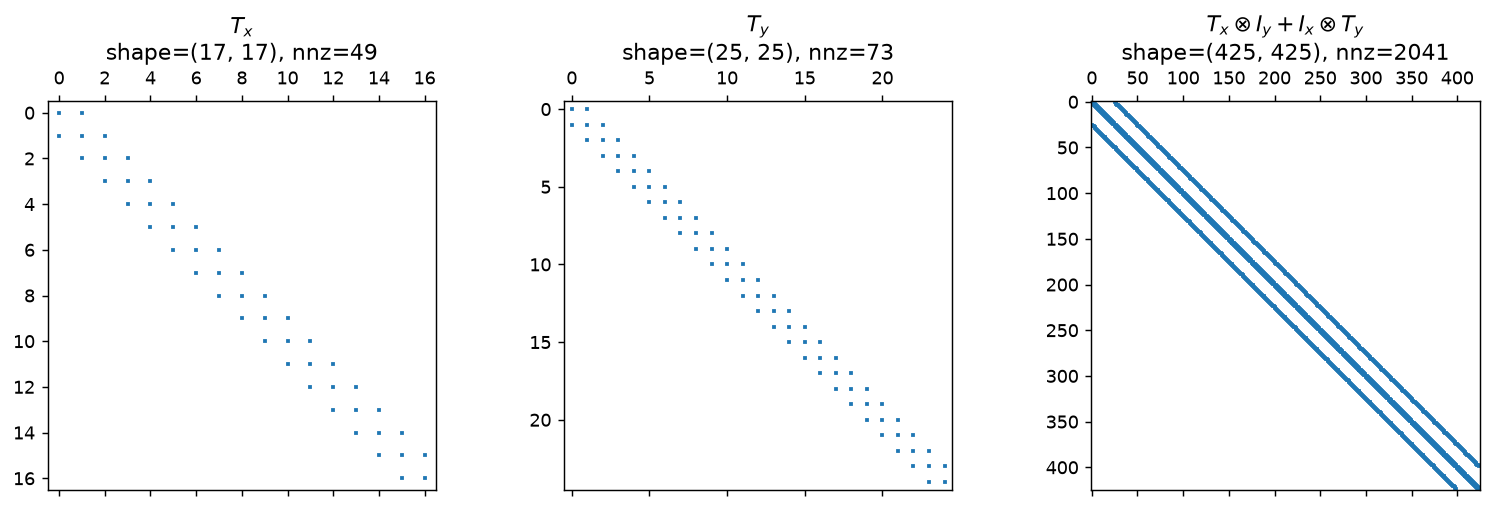

dense entries: 180625
stored sparse entries: 2041


In [3]:
def dirichlet_kinetic(size):
    return sparse.diags(
        (-np.ones(size - 1), 2.0 * np.ones(size), -np.ones(size - 1)),
        offsets=(-1, 0, 1),
        format="csr",
    )

nx, ny = 17, 25
Tx = dirichlet_kinetic(nx)
Ty = dirichlet_kinetic(ny)
Ix = sparse.identity(nx, format="csr")
Iy = sparse.identity(ny, format="csr")
T2 = sparse.kron(Tx, Iy, format="csr") + sparse.kron(Ix, Ty, format="csr")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for axis, matrix, title in zip(
    axes,
    (Tx, Ty, T2),
    (r"$T_x$", r"$T_y$", r"$T_x\otimes I_y+I_x\otimes T_y$"),
):
    axis.spy(matrix, markersize=1.5)
    axis.set_title(f"{title}\nshape={matrix.shape}, nnz={matrix.nnz}")
plt.show()
print(f"dense entries: {T2.shape[0] * T2.shape[1]}")
print(f"stored sparse entries: {T2.nnz}")


## 4. Eigenvalues and separable eigenmodes

If

$$
T_xu_i=\lambda_i^{(x)}u_i,
\qquad
T_yv_j=\lambda_j^{(y)}v_j,
$$

then

$$
T_{2D}(u_i\otimes v_j)
=
\left(\lambda_i^{(x)}+\lambda_j^{(y)}\right)(u_i\otimes v_j).
$$

Thus the two-dimensional eigenvalues are pairwise sums, and the corresponding fields are separable outer products.

maximum eigenvalue-sum error: 2.132e-14
selected-mode residual: 2.300e-15
outer-product reshape error: 0.000e+00


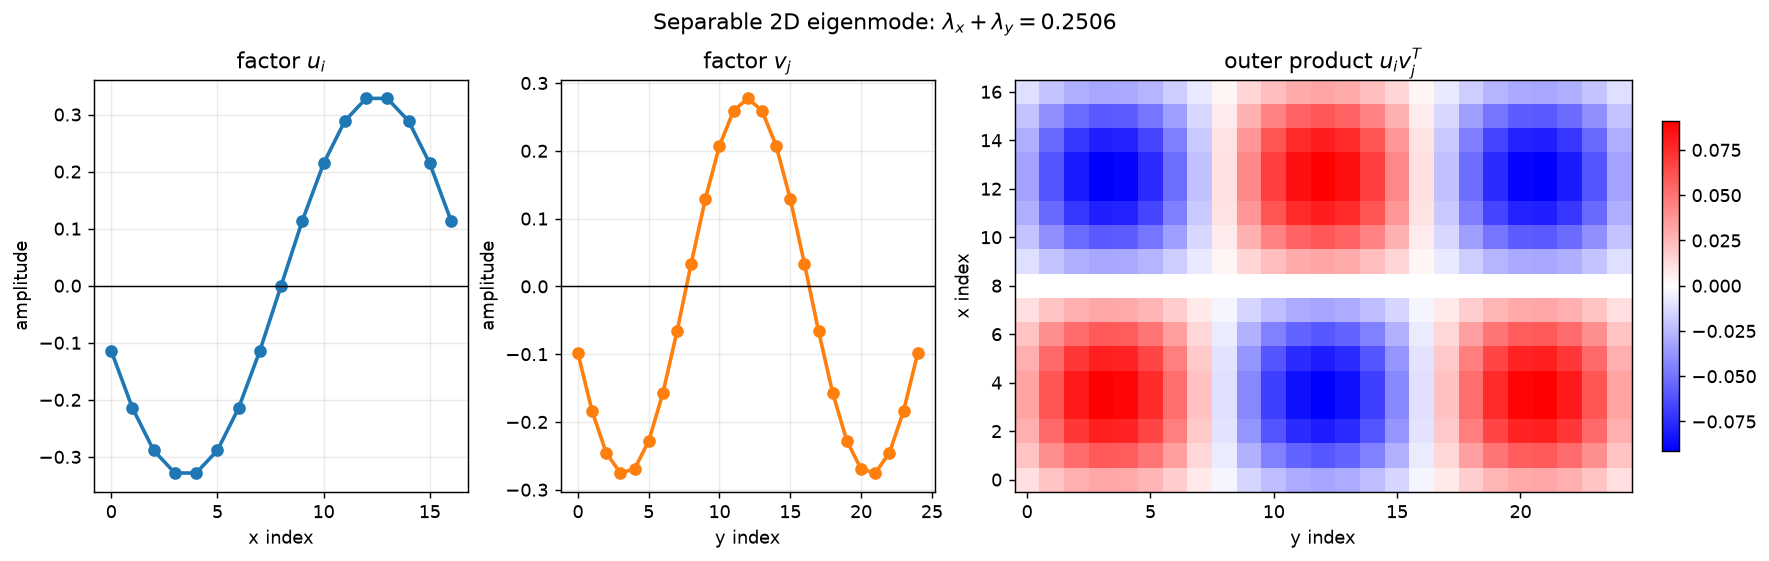

In [4]:
lambda_x, vectors_x = np.linalg.eigh(Tx.toarray())
lambda_y, vectors_y = np.linalg.eigh(Ty.toarray())
expected_2d = np.sort((lambda_x[:, None] + lambda_y[None, :]).ravel())
computed_2d = np.linalg.eigvalsh(T2.toarray())
print(f"maximum eigenvalue-sum error: {np.max(np.abs(expected_2d - computed_2d)):.3e}")

mode_x, mode_y = 1, 2
product_vector = np.kron(vectors_x[:, mode_x], vectors_y[:, mode_y])
mode_energy = lambda_x[mode_x] + lambda_y[mode_y]
residual = np.linalg.norm(T2 @ product_vector - mode_energy * product_vector)
field = product_vector.reshape((nx, ny), order="C")
print(f"selected-mode residual: {residual:.3e}")

mode_u = vectors_x[:, mode_x]
mode_v = vectors_y[:, mode_y]
outer_product_error = np.linalg.norm(field - np.outer(mode_u, mode_v))
print(f"outer-product reshape error: {outer_product_error:.3e}")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
    gridspec_kw={"width_ratios": (1.0, 1.0, 1.65)},
    constrained_layout=True,
)
axes[0].plot(np.arange(nx), mode_u, marker="o", linewidth=2.0)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_xlabel("x index")
axes[0].set_ylabel("amplitude")
axes[0].set_title(r"factor $u_i$")
axes[0].grid(alpha=0.25)

axes[1].plot(np.arange(ny), mode_v, marker="o", linewidth=2.0, color="tab:orange")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("y index")
axes[1].set_ylabel("amplitude")
axes[1].set_title(r"factor $v_j$")
axes[1].grid(alpha=0.25)

HeatMapVisualizer(field).plot(
    axes[2],
    origin="lower",
    aspect="auto",
    title=r"outer product $u_i v_j^T$",
    xlabel="y index",
    ylabel="x index",
)
fig.suptitle(
    rf"Separable 2D eigenmode: $\lambda_x+\lambda_y={mode_energy:.4f}$"
)
plt.show()


## 5. Interpretation and cautions

- $A\otimes B$ is a product; $A\otimes I+I\otimes B$ is a Kronecker sum.
- Shape and flattening conventions are part of the representation. Changing from C to Fortran order changes which factor acts on the fastest index.
- Kronecker structure is exact only when the multidimensional operator is separable in the selected coordinates and boundary conditions.
- Mixed derivatives, nonorthogonal coordinates, position-dependent couplings, and irregular domains generally add terms or destroy the simple sum.
- Sparse Kronecker construction saves storage, but explicit matrices can still grow rapidly. Matrix-free application may be preferable for large problems.

The same construction underlies multidimensional particle-in-a-box Hamiltonians, separable finite-difference Laplacians, lattice models with internal degrees of freedom, and many-body product spaces.